In [3]:
!pip install --quiet numpy pandas matplotlib seaborn scikit-learn
print("\n Installation done or package already present")


 Installation done or package already present


In [4]:
# Basic imports used throughout the notebook
import os
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn utilities we'll use
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Use seaborn's styling
sns.set_style("whitegrid")
sns.set_context("notebook")

#opening the folder where the csv file is
folder = r"C:\Users\lovey\OneDrive\Desktop\DataSets"
os.listdir(folder)

print("Notebook imports done.")


Notebook imports done.


In [5]:
# show where data is expected
DATA_PATH = r"C:\Users\lovey\OneDrive\Desktop\DataSets\air_quality_health_dataset.csv"
print("Data path set to:", DATA_PATH)

Data path set to: C:\Users\lovey\OneDrive\Desktop\DataSets\air_quality_health_dataset.csv


In [6]:
#load csv and show first 10 rows
DATA_PATH = r"C:\Users\lovey\OneDrive\Desktop\DataSets\air_quality_health_dataset.csv"

df = pd.read_csv(DATA_PATH)
print("loaded dataframe. Shape",df.shape)
display(df.head(10))

loaded dataframe. Shape (3000, 26)


,date,region,AQI,PM2.5,PM10,NO2,SO2,CO,O3,temperature,...,school_closures,public_transport_usage,mask_usage_rate,lockdown_status,industrial_activity,vehicle_count,construction_activity,respiratory_admissions,population_density,green_cover_percentage
0,01-01-2020,East,109.934283,31.382887,57.718373,47.654022,25.874070,0.956973,32.574682,37.555663,...,0,43.103376,75.706162,0,66.098466,9757,63.001573,11,1957.637287,42.348419
1,02-01-2020,Central,97.234714,47.094225,67.381383,50.734127,10.605095,0.990203,23.749138,24.900342,...,0,30.606591,69.652802,0,107.686174,9157,6.417798,13,2962.769470,27.712735
2,03-01-2020,East,112.953771,53.795917,61.158796,44.986899,18.361025,1.019288,35.530851,23.437165,...,0,13.037424,82.561183,1,77.445192,2058,66.001849,3,6912.007043,41.031516
3,04-01-2020,West,130.460597,88.315315,69.040084,20.575023,19.791700,1.284058,25.277106,22.388200,...,0,8.974779,73.642836,0,51.864000,8726,79.580923,6,9227.543628,40.543537
4,05-01-2020,South,95.316933,68.348297,75.716994,38.445776,20.079543,0.775835,35.996440,26.881835,...,1,96.022689,68.688106,0,148.714488,9720,6.301105,8,1277.810175,5.648920
5,06-01-2020,South,95.317261,39.967776,96.743090,28.442924,20.902480,0.746096,27.807108,26.932913,...,0,99.515344,67.393778,0,121.617654,4069,84.842058,9,6428.622693,47.149910
6,07-01-2020,West,131.584256,67.290544,73.576819,37.973942,23.052199,1.370986,16.231623,29.753139,...,0,89.792538,57.895350,0,123.546323,2500,12.335902,8,3831.189452,19.034779
7,08-01-2020,West,115.348695,36.790440,48.287486,49.800042,19.822963,0.861207,22.140670,20.369689,...,0,45.863143,76.470659,0,116.295865,8068,17.583370,13,3284.793439,41.342931
8,09-01-2020,North,90.610512,76.240366,102.801357,43.051508,18.159709,0.621089,26.556682,23.437526,...,0,80.791576,75.992329,0,64.373847,4705,83.640354,8,1882.424687,63.199856
9,10-01-2020,East,110.851201,52.933130,63.258197,51.480909,17.962053,0.854461,40.945512,35.152729,...,0,83.428220,79.538477,0,70.669442,8036,12.470203,11,8892.778335,17.498740


In [7]:
#inspecting the dataframe

print("Shape",df.shape)

print("\n column name")
print(list(df.columns))

print("\n Data Type: ")
print(df.dtypes)

print("\n Missing values per columns")
print(df.isna().sum().sort_values(ascending=False))

Shape (3000, 26)

 column name
['date', 'region', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'hospital_visits', 'emergency_visits', 'mobility_index', 'school_closures', 'public_transport_usage', 'mask_usage_rate', 'lockdown_status', 'industrial_activity', 'vehicle_count', 'construction_activity', 'respiratory_admissions', 'population_density', 'green_cover_percentage']

 Data Type: 
date                       object
region                     object
AQI                       float64
PM2.5                     float64
PM10                      float64
NO2                       float64
SO2                       float64
CO                        float64
O3                        float64
temperature               float64
humidity                  float64
wind_speed                float64
precipitation             float64
hospital_visits             int64
emergency_visits            int64
mobility_index            float64
schoo

In [8]:
# Prepare x(features) and y(targets)

#Target
y = df["AQI"]

#List numeric features
numeric_features = ['PM2.5','PM10','NO2','SO2','CO','O3','temperature','humidity','wind_speed','precipitation','hospital_visits','emergency_visits','mobility_index','school_closures','public_transport_usage','mask_usage_rate','lockdown_status','industrial_activity','vehicle_count','construction_activity','respiratory_admissions','population_density','green_cover_percentage']

#Categorical features 
categorical_features = ['region']

#Build feature matrix 
x = df[numeric_features + categorical_features].copy()

x.head()

,PM2.5,PM10,NO2,SO2,CO,O3,temperature,humidity,wind_speed,precipitation,...,public_transport_usage,mask_usage_rate,lockdown_status,industrial_activity,vehicle_count,construction_activity,respiratory_admissions,population_density,green_cover_percentage,region
0,31.382887,57.718373,47.654022,25.874070,0.956973,32.574682,37.555663,20.542799,5.204995,0.179832,...,43.103376,75.706162,0,66.098466,9757,63.001573,11,1957.637287,42.348419,East
1,47.094225,67.381383,50.734127,10.605095,0.990203,23.749138,24.900342,27.308785,6.235446,3.278768,...,30.606591,69.652802,0,107.686174,9157,6.417798,13,2962.769470,27.712735,Central
2,53.795917,61.158796,44.986899,18.361025,1.019288,35.530851,23.437165,80.055977,5.673999,1.502239,...,13.037424,82.561183,1,77.445192,2058,66.001849,3,6912.007043,41.031516,East
3,88.315315,69.040084,20.575023,19.791700,1.284058,25.277106,22.388200,25.929988,8.496463,9.061902,...,8.974779,73.642836,0,51.864000,8726,79.580923,6,9227.543628,40.543537,West
4,68.348297,75.716994,38.445776,20.079543,0.775835,35.996440,26.881835,34.946343,1.184104,1.758327,...,96.022689,68.688106,0,148.714488,9720,6.301105,8,1277.810175,5.648920,South


In [9]:
#test_train split cell 

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print("Training set shape",x_train.shape)
print("Test set shape",x_test.shape)

Training set shape (2400, 24)
Test set shape (600, 24)


In [10]:
# Build pipeline and fit model

# numeric_features and categorical_features should already exist from your earlier cell.
# They are lists of column names.

# 1) Define transformers:
# - 'num' will standardize numeric columns (zero mean, unit variance).
#   This helps many models and keeps feature scales comparable.
# - 'cat' will one-hot encode the 'region' categorical column. handle_unknown='ignore'
#   ensures the transformer won't break if a new region appears during prediction.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop"  # drop any columns not listed in transformers (none expected)
)

# 2) Create a pipeline that first preprocesses, then fits a LinearRegression model.
# Pipeline ensures the same preprocessing is applied to training and test (and new) data.
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# 3) Fit the pipeline to the training data.
# This runs the StandardScaler.fit_transform on numeric_features,
# OneHotEncoder.fit on categorical_features, then fits LinearRegression on resulting features.
model_pipeline.fit(x_train, y_train)

print("Pipeline fitted. You can now predict with model_pipeline.predict(X_new).")


Pipeline fitted. You can now predict with model_pipeline.predict(X_new).


In [11]:
# Predict and evaluate

#1) predict AQI for the test set
y_pred = model_pipeline.predict(x_test)

#2) Compute common regression metrics
mse = mean_squared_error(y_test,y_pred)    #mean square error
rmse = np.sqrt(mse)    #root mean square error(same units as AQI)
mae = mean_absolute_error(y_test,y_pred)  #absolute mean error(robust to outliers)
r2 = r2_score(y_test,y_pred)   #R^2(Explained variance)

# 3) Print results nicely
print(f"Evaluation on test set:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE : {mae:.4f}")
print(f"  R^2 : {r2:.4f}")

Evaluation on test set:
  RMSE: 19.9612
  MAE : 15.9010
  R^2 : -0.0109


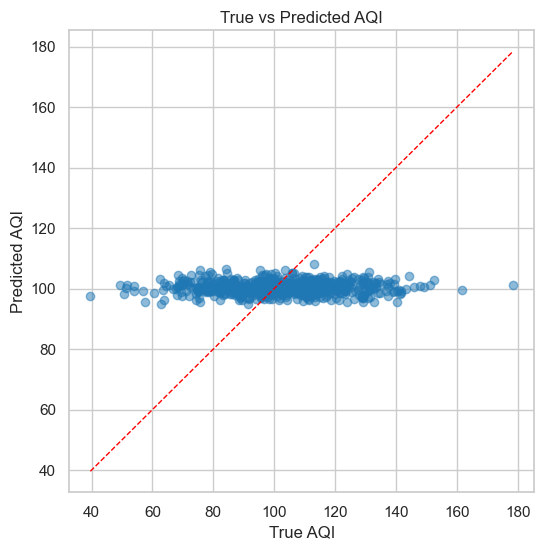

In [12]:
# Cell C: Visualization of predictions vs true values

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
# Plot diagonal line y=x for reference
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
plt.xlabel("True AQI")
plt.ylabel("Predicted AQI")
plt.title("True vs Predicted AQI")
plt.grid(True)
plt.show()


In [13]:
# Cell D: Extract and display model coefficients mapped to original feature names

import numpy as np
import pandas as pd

# 1) Get the fitted preprocessor and regressor from the pipeline
preproc = model_pipeline.named_steps["preprocessor"]
reg = model_pipeline.named_steps["regressor"]

# 2) Numeric feature names (order preserved as we defined earlier)
num_feats = numeric_features[:]  # copy to be safe

# 3) One-hot encoded categorical names
ohe_feature_names = []
# Access the fitted OneHotEncoder inside the ColumnTransformer
ohe = preproc.named_transformers_.get("cat", None)

if ohe is not None:
    # sklearn >= 1.0 provides get_feature_names_out
    if hasattr(ohe, "get_feature_names_out"):
        # this returns names like "region_<category>"
        ohe_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
    else:
        # fallback for very old sklearn: derive names from categories_
        categories = ohe.categories_
        for col, cats in zip(categorical_features, categories):
            ohe_feature_names += [f"{col}__{c}" for c in cats]

# 4) Combined feature names in the order the regressor expects
feature_names = num_feats + ohe_feature_names

# 5) Get coefficients (matching the order above) and intercept
coefficients = reg.coef_
intercept = reg.intercept_

# 6) Build DataFrame to view coefficients with absolute magnitude sorting
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coeff": np.abs(coefficients)
}).sort_values(by="abs_coeff", ascending=False).reset_index(drop=True)

# 7) Print intercept and show coefficient table
print("Intercept (bias):", intercept)
display(coef_df.head(50))  # show top 50 (or fewer) features by absolute coefficient


Intercept (bias): 4823438008915.082


,feature,coefficient,abs_coeff
0,region_Central,-4.823438e+12,4.823438e+12
1,region_North,-4.823438e+12,4.823438e+12
2,region_South,-4.823438e+12,4.823438e+12
3,region_West,-4.823438e+12,4.823438e+12
4,region_East,-4.823438e+12,4.823438e+12
5,temperature,-7.483385e-01,7.483385e-01
6,emergency_visits,6.969149e-01,6.969149e-01
7,precipitation,-6.857057e-01,6.857057e-01
8,CO,-4.753597e-01,4.753597e-01
9,vehicle_count,4.225651e-01,4.225651e-01


In [16]:
import joblib

model_file = r"C:\Users\lovey\OneDrive\Desktop\DataSets\aqi_model_pipeline.joblib"

joblib.dump(model_pipeline, model_file)

print("Saved model pipeline to:", model_file)


Saved model pipeline to: C:\Users\lovey\OneDrive\Desktop\DataSets\aqi_model_pipeline.joblib
